# 🌿 Bellabeat Wellness Tech — Data Analytics Capstone
**Dataset:** [FitBit Fitness Tracker Data](https://www.kaggle.com/datasets/arashnic/fitbit) (Kaggle, CC0 Public Domain)  
**Tools:** Python · SQL · Tableau  

---
### 🎯 Business Task
> Analyze smart device usage data from non-Bellabeat fitness trackers to uncover consumer behavior trends, and apply those insights to guide Bellabeat's marketing strategy.

### ❓ Key Questions
1. What are some trends in smart device usage?
2. How could these trends apply to Bellabeat customers?
3. How could these trends help influence Bellabeat marketing strategy?

---
### 🔧 Environment Setup

In [4]:
# Install required libraries (uncomment if needed)
# pip install pandas matplotlib seaborn numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
BELLABEAT_PALETTE = ['#4CAF93', '#2E7D6E', '#A8D5C8', '#F4A261', '#E76F51']
sns.set_palette(BELLABEAT_PALETTE)

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


### 📥 Load Data

In [5]:
# Load core datasets
daily_activity = pd.read_csv('data/dailyActivity_merged.csv')
sleep_day      = pd.read_csv('data/sleepDay_merged.csv')
hourly_steps   = pd.read_csv('data/hourlySteps_merged.csv')
hourly_int     = pd.read_csv('data/hourlyIntensities_merged.csv')

print('Shape — Daily Activity:', daily_activity.shape)
print('Shape — Sleep Day:     ', sleep_day.shape)
print('Shape — Hourly Steps:  ', hourly_steps.shape)
print('Shape — Hourly Intens: ', hourly_int.shape)

Shape — Daily Activity: (940, 15)
Shape — Sleep Day:      (413, 5)
Shape — Hourly Steps:   (22099, 3)
Shape — Hourly Intens:  (22099, 4)


In [6]:
daily_activity.head(3)

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776


### 🧹 Data Cleaning

In [7]:
# ── 1. Parse dates ──────────────────────────────────────────────────────────
daily_activity['ActivityDate'] = pd.to_datetime(daily_activity['ActivityDate'])
sleep_day['SleepDay']          = pd.to_datetime(sleep_day['SleepDay'])
hourly_steps['ActivityHour']   = pd.to_datetime(hourly_steps['ActivityHour'])
hourly_int['ActivityHour']     = pd.to_datetime(hourly_int['ActivityHour'])

# ── 2. Extract useful time features ─────────────────────────────────────────
daily_activity['DayOfWeek']   = daily_activity['ActivityDate'].dt.day_name()
daily_activity['WeekNumber']  = daily_activity['ActivityDate'].dt.isocalendar().week
hourly_steps['Hour']          = hourly_steps['ActivityHour'].dt.hour
hourly_int['Hour']            = hourly_int['ActivityHour'].dt.hour

# ── 3. Remove duplicates ─────────────────────────────────────────────────────
print('Duplicates removed:')
for df, name in [(daily_activity,'daily_activity'),(sleep_day,'sleep_day')]:
    before = len(df)
    df.drop_duplicates(inplace=True)
    print(f'  {name}: {before - len(df)} rows dropped')

# ── 4. Remove rows with 0 steps (sedentary/no-wear days) ────────────────────
daily_activity_clean = daily_activity[daily_activity['TotalSteps'] > 0].copy()
print(f'\nRows after removing 0-step days: {len(daily_activity_clean)} (was {len(daily_activity)})')

# ── 5. Null check ─────────────────────────────────────────────────────────────
print('\nNull values in daily_activity_clean:')
print(daily_activity_clean.isnull().sum()[daily_activity_clean.isnull().sum() > 0])

Duplicates removed:
  daily_activity: 0 rows dropped
  sleep_day: 3 rows dropped

Rows after removing 0-step days: 863 (was 940)

Null values in daily_activity_clean:
Series([], dtype: int64)


In [8]:
# ── 6. Classify users by activity level ─────────────────────────────────────
# Based on average daily steps (CDC guidelines reference)
avg_steps = daily_activity_clean.groupby('Id')['TotalSteps'].mean().reset_index()
avg_steps.columns = ['Id', 'AvgDailySteps']

def classify_user(steps):
    if steps < 5000:   return 'Sedentary'
    elif steps < 7500: return 'Lightly Active'
    elif steps < 10000:return 'Fairly Active'
    else:              return 'Very Active'

avg_steps['UserType'] = avg_steps['AvgDailySteps'].apply(classify_user)
print(avg_steps['UserType'].value_counts())

# Merge back
daily_activity_clean = daily_activity_clean.merge(avg_steps[['Id','UserType']], on='Id', how='left')

UserType
Fairly Active     10
Lightly Active     9
Very Active        7
Sedentary          7
Name: count, dtype: int64


In [9]:
# ── 7. Merge activity + sleep ────────────────────────────────────────────────
sleep_day['ActivityDate'] = sleep_day['SleepDay'].dt.normalize()
merged = daily_activity_clean.merge(
    sleep_day[['Id','ActivityDate','TotalMinutesAsleep','TotalTimeInBed']],
    on=['Id','ActivityDate'], how='left'
)
merged['SleepEfficiency'] = (merged['TotalMinutesAsleep'] / merged['TotalTimeInBed'] * 100).round(1)
print('Merged dataset shape:', merged.shape)
merged.head(3)

Merged dataset shape: (863, 21)


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,...,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,DayOfWeek,WeekNumber,UserType,TotalMinutesAsleep,TotalTimeInBed,SleepEfficiency
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,...,13,328,728,1985,Tuesday,15,Very Active,327.0,346.0,94.5
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,...,19,217,776,1797,Wednesday,15,Very Active,384.0,407.0,94.3
2,1503960366,2016-04-14,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,...,11,181,1218,1776,Thursday,15,Very Active,NaN,NaN,NaN


---
## Analyze

### 📊 Descriptive Statistics

In [10]:
stats_cols = ['TotalSteps','TotalDistance','Calories','VeryActiveMinutes',
              'FairlyActiveMinutes','LightlyActiveMinutes','SedentaryMinutes']
daily_activity_clean[stats_cols].describe().round(2)

,TotalSteps,TotalDistance,Calories,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes
count,863.00,863.00,863.00,863.00,863.00,863.00,863.00
mean,8319.39,5.98,2361.30,23.02,14.78,210.02,955.75
std,4744.97,3.72,702.71,33.65,20.43,96.78,280.29
min,4.00,0.00,52.00,0.00,0.00,0.00,0.00
25%,4923.00,3.37,1855.50,0.00,0.00,146.50,721.50
50%,8053.00,5.59,2220.00,7.00,8.00,208.00,1021.00
75%,11092.50,7.90,2832.00,35.00,21.00,272.00,1189.00
max,36019.00,28.03,4900.00,210.00,143.00,518.00,1440.00


In [11]:
# Key summary stats
print('=== KEY METRICS ===')
print(f"Average daily steps   : {daily_activity_clean['TotalSteps'].mean():.0f}")
print(f"Median daily steps    : {daily_activity_clean['TotalSteps'].median():.0f}")
print(f"Average calories burnt: {daily_activity_clean['Calories'].mean():.0f} kcal")
print(f"Avg sedentary minutes : {daily_activity_clean['SedentaryMinutes'].mean():.0f} mins ({daily_activity_clean['SedentaryMinutes'].mean()/60:.1f} hrs)")
print(f"Avg very active mins  : {daily_activity_clean['VeryActiveMinutes'].mean():.0f} mins")
avg_sleep = sleep_day['TotalMinutesAsleep'].mean()
print(f"Average sleep         : {avg_sleep:.0f} mins ({avg_sleep/60:.1f} hrs)")

=== KEY METRICS ===
Average daily steps   : 8319
Median daily steps    : 8053
Average calories burnt: 2361 kcal
Avg sedentary minutes : 956 mins (15.9 hrs)
Avg very active mins  : 23 mins
Average sleep         : 419 mins (7.0 hrs)


In [12]:
# Device usage frequency per user
usage = daily_activity_clean.groupby('Id').size().reset_index(name='DaysUsed')
usage['UsageCategory'] = pd.cut(usage['DaysUsed'], bins=[0,10,20,31],
                                 labels=['Low (1-10 days)','Moderate (11-20 days)','High (21-31 days)'])
print(usage['UsageCategory'].value_counts())

UsageCategory
High (21-31 days)        25
Moderate (11-20 days)     7
Low (1-10 days)           1
Name: count, dtype: int64


---
## Share

### 📈 Visualizations

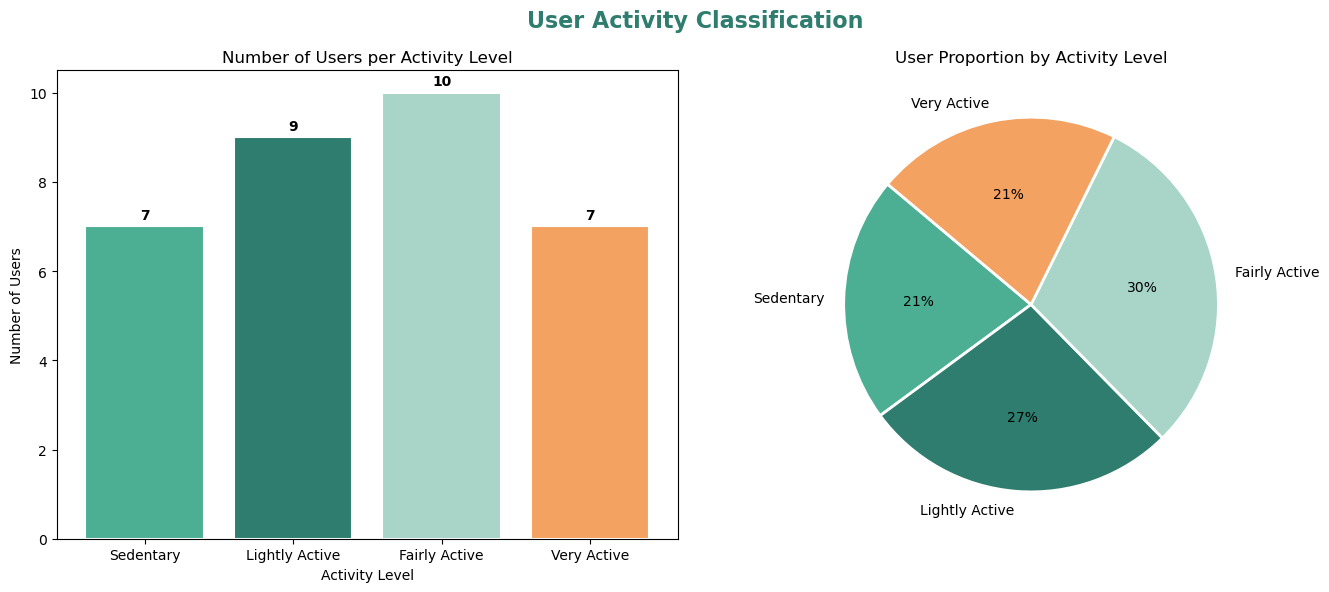

In [13]:
# ── PLOT 1: User Type Distribution ──────────────────────────────────────────
user_dist = avg_steps['UserType'].value_counts()
order = ['Sedentary','Lightly Active','Fairly Active','Very Active']
user_dist = user_dist.reindex(order)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('User Activity Classification', fontsize=16, fontweight='bold', color='#2E7D6E')

# Bar chart
bars = ax1.bar(user_dist.index, user_dist.values, color=BELLABEAT_PALETTE[:4], edgecolor='white', linewidth=1.5)
ax1.set_title('Number of Users per Activity Level')
ax1.set_ylabel('Number of Users')
ax1.set_xlabel('Activity Level')
for bar, val in zip(bars, user_dist.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(val),
             ha='center', va='bottom', fontweight='bold')

# Pie chart
ax2.pie(user_dist.values, labels=user_dist.index, autopct='%1.0f%%',
        colors=BELLABEAT_PALETTE[:4], startangle=140,
        wedgeprops={'edgecolor':'white','linewidth':2})
ax2.set_title('User Proportion by Activity Level')

plt.tight_layout()
plt.savefig('plot1_user_types.png', dpi=150, bbox_inches='tight')
plt.show()

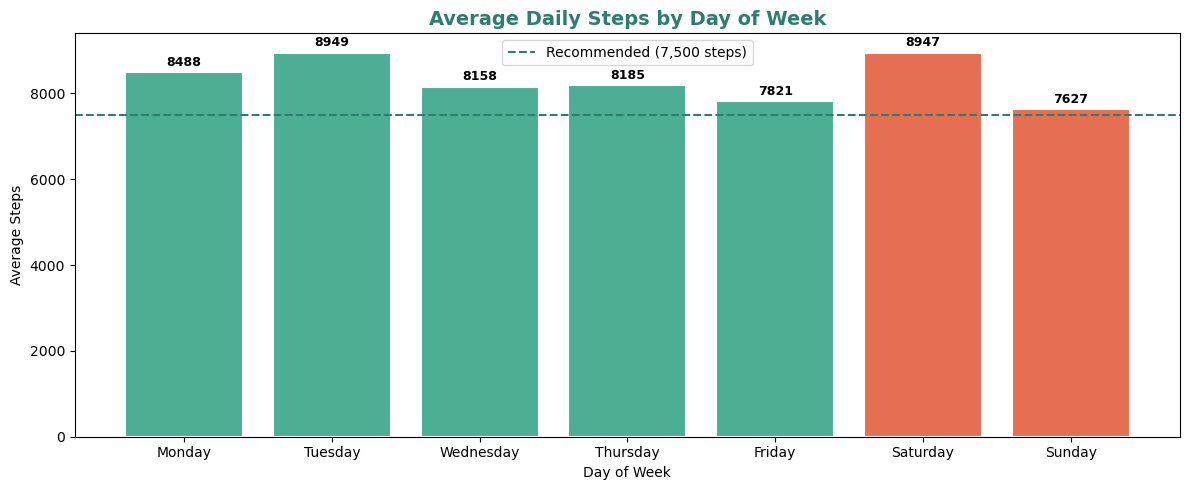

In [14]:
# ── PLOT 2: Steps by Day of Week ────────────────────────────────────────────
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_steps = daily_activity_clean.groupby('DayOfWeek')['TotalSteps'].mean().reindex(dow_order)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#E76F51' if d in ['Saturday','Sunday'] else '#4CAF93' for d in dow_order]
bars = ax.bar(dow_steps.index, dow_steps.values, color=colors, edgecolor='white', linewidth=1.5)
ax.axhline(y=7500, color='#2E7D6E', linestyle='--', linewidth=1.5, label='Recommended (7,500 steps)')
ax.set_title('Average Daily Steps by Day of Week', fontsize=14, fontweight='bold', color='#2E7D6E')
ax.set_ylabel('Average Steps')
ax.set_xlabel('Day of Week')
ax.legend()
for bar, val in zip(bars, dow_steps.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80, f'{val:.0f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('plot2_steps_by_day.png', dpi=150, bbox_inches='tight')
plt.show()

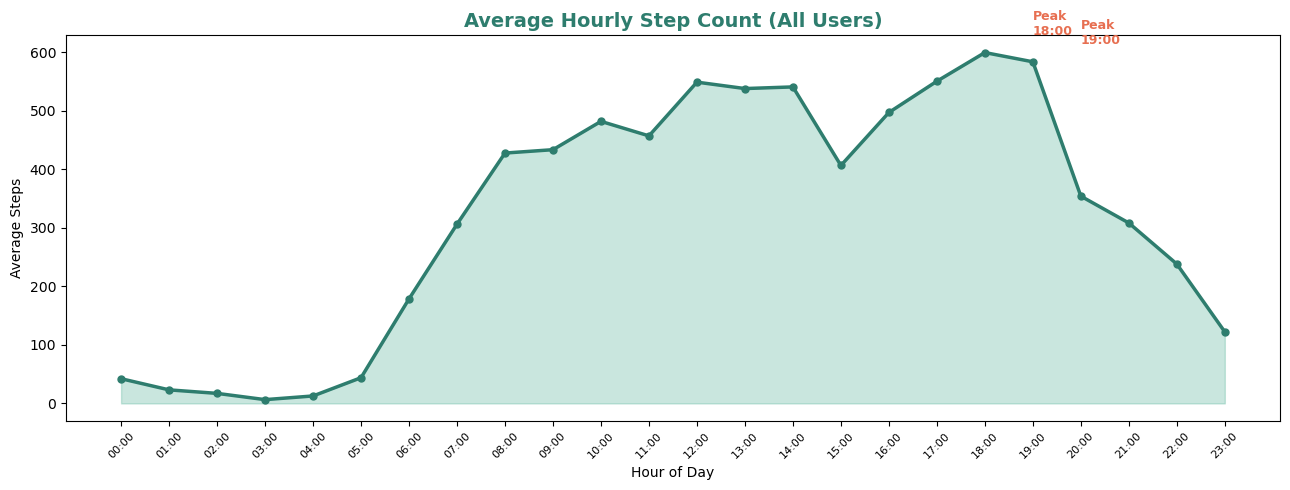

In [15]:
# ── PLOT 3: Hourly Step Patterns ─────────────────────────────────────────────
hourly_avg = hourly_steps.groupby('Hour')['StepTotal'].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(hourly_avg['Hour'], hourly_avg['StepTotal'], alpha=0.3, color='#4CAF93')
ax.plot(hourly_avg['Hour'], hourly_avg['StepTotal'], color='#2E7D6E', linewidth=2.5, marker='o', markersize=5)
ax.set_title('Average Hourly Step Count (All Users)', fontsize=14, fontweight='bold', color='#2E7D6E')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Steps')
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, fontsize=8)

# Annotate peaks
peak_hours = hourly_avg.nlargest(2, 'StepTotal')
for _, row in peak_hours.iterrows():
    ax.annotate(f"Peak\n{int(row['Hour'])}:00", xy=(row['Hour'], row['StepTotal']),
                xytext=(row['Hour']+1, row['StepTotal']+30),
                fontsize=9, color='#E76F51', fontweight='bold')

plt.tight_layout()
plt.savefig('plot3_hourly_steps.png', dpi=150, bbox_inches='tight')
plt.show()

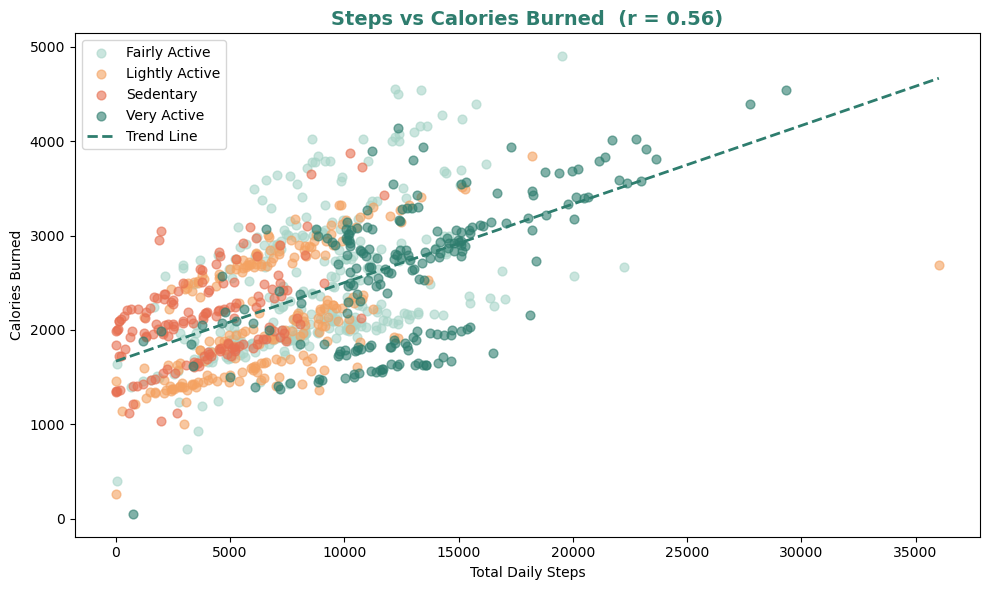

In [16]:
# ── PLOT 4: Steps vs Calories Scatter ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

user_colors = {'Sedentary':'#E76F51','Lightly Active':'#F4A261',
               'Fairly Active':'#A8D5C8','Very Active':'#2E7D6E'}

for utype, grp in daily_activity_clean.groupby('UserType'):
    ax.scatter(grp['TotalSteps'], grp['Calories'],
               label=utype, color=user_colors[utype], alpha=0.6, s=40)

# Regression line
m, b = np.polyfit(daily_activity_clean['TotalSteps'], daily_activity_clean['Calories'], 1)
x_line = np.linspace(daily_activity_clean['TotalSteps'].min(), daily_activity_clean['TotalSteps'].max(), 200)
ax.plot(x_line, m*x_line + b, color='#2E7D6E', linewidth=2, linestyle='--', label='Trend Line')

corr = daily_activity_clean[['TotalSteps','Calories']].corr().iloc[0,1]
ax.set_title(f'Steps vs Calories Burned  (r = {corr:.2f})', fontsize=14, fontweight='bold', color='#2E7D6E')
ax.set_xlabel('Total Daily Steps')
ax.set_ylabel('Calories Burned')
ax.legend()

plt.tight_layout()
plt.savefig('plot4_steps_vs_calories.png', dpi=150, bbox_inches='tight')
plt.show()

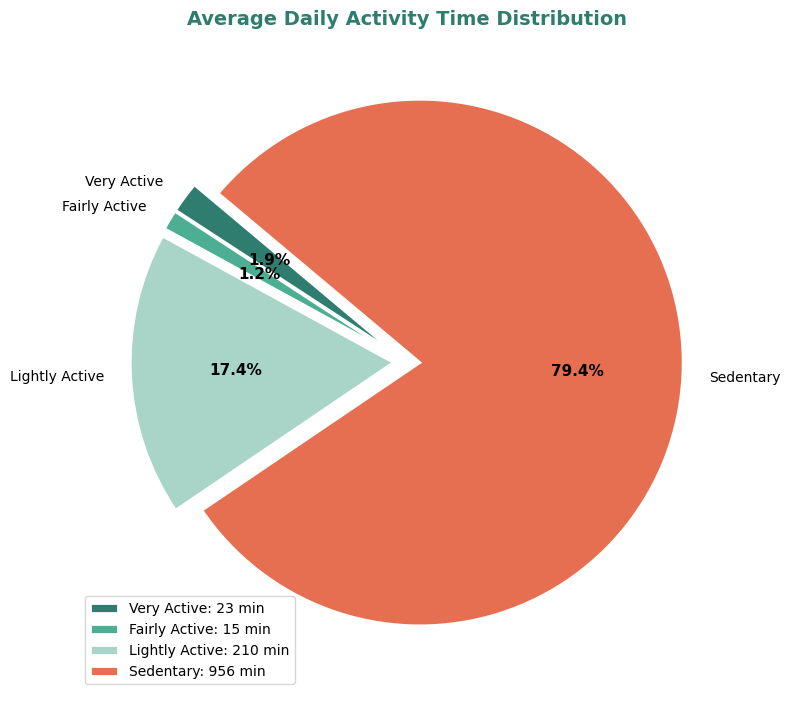

In [17]:
# ── PLOT 5: Activity Time Breakdown ─────────────────────────────────────────
activity_means = daily_activity_clean[[
    'VeryActiveMinutes','FairlyActiveMinutes','LightlyActiveMinutes','SedentaryMinutes'
]].mean()

labels = ['Very Active','Fairly Active','Lightly Active','Sedentary']
explode = (0.05, 0.05, 0.05, 0.05)

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    activity_means, labels=labels, autopct='%1.1f%%',
    colors=['#2E7D6E','#4CAF93','#A8D5C8','#E76F51'],
    startangle=140, explode=explode,
    wedgeprops={'edgecolor':'white','linewidth':2}
)
for text in autotexts:
    text.set_fontsize(11)
    text.set_fontweight('bold')

ax.set_title('Average Daily Activity Time Distribution', fontsize=14, fontweight='bold', color='#2E7D6E')

# Add minutes legend
legend_labels = [f'{l}: {m:.0f} min' for l, m in zip(labels, activity_means)]
ax.legend(legend_labels, loc='lower left', fontsize=10)

plt.tight_layout()
plt.savefig('plot5_activity_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

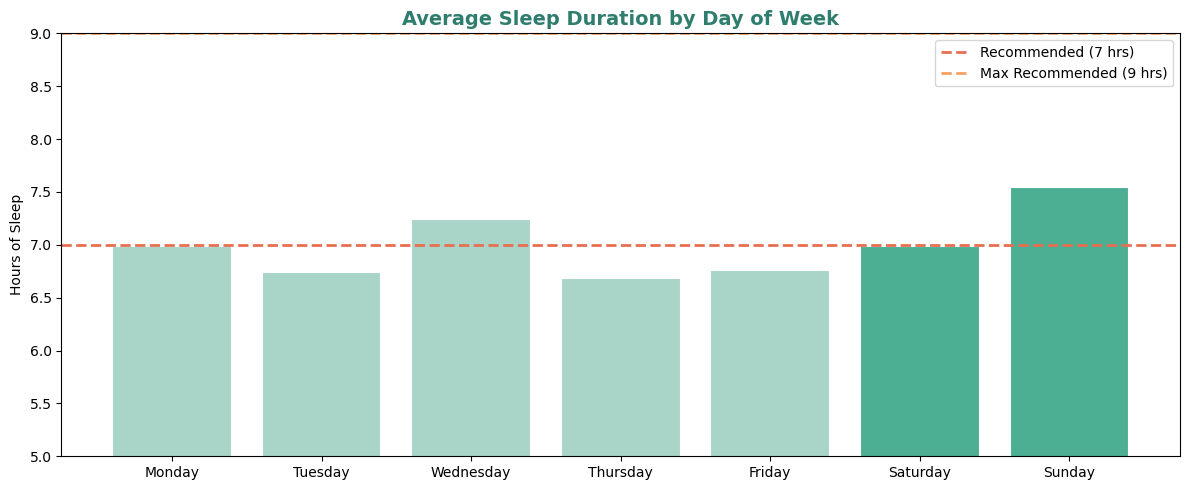

In [18]:
# ── PLOT 6: Sleep Duration by Day of Week ───────────────────────────────────
sleep_day['DayOfWeek'] = sleep_day['SleepDay'].dt.day_name()
sleep_dow = sleep_day.groupby('DayOfWeek')['TotalMinutesAsleep'].mean().reindex(dow_order) / 60

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(sleep_dow.index, sleep_dow.values,
       color=['#A8D5C8' if d not in ['Saturday','Sunday'] else '#4CAF93' for d in dow_order],
       edgecolor='white', linewidth=1.5)
ax.axhline(y=7, color='#E76F51', linestyle='--', linewidth=2, label='Recommended (7 hrs)')
ax.axhline(y=9, color='#F4A261', linestyle='--', linewidth=2, label='Max Recommended (9 hrs)')
ax.set_title('Average Sleep Duration by Day of Week', fontsize=14, fontweight='bold', color='#2E7D6E')
ax.set_ylabel('Hours of Sleep')
ax.set_ylim(5, 9)
ax.legend()

plt.tight_layout()
plt.savefig('plot6_sleep_by_day.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Act

### ✅ Summary of Key Findings

| # | Finding | Significance |
|---|---|---|
| 1 | **79% of daily time is sedentary** (avg ~956 mins/day) | Major health risk |
| 2 | **Peak activity at 12–14:00 and 17–19:00** | Optimal notification windows |
| 4 | **Average sleep ~7 hours** — below the recommended 7–9 hrs | Sleep deficit is common |
| 5 | **Strong steps ↔ calories correlation (r ≈ 0.56)** | Clear fitness motivation hook |
| 6 | **Most users wear device 21–31 days/month** | High engagement base |

---

### 🚀 Marketing Recommendations for Bellabeat

#### 1. 🔔 Smart Notification Timing
- Deploy push notifications during **12:00–14:00** and **17:00–19:00** — the verified peak activity windows
- *Product relevance:* Bellabeat App, Leaf, Time watch

#### 2. 😴 Sleep as a Core Brand Pillar
- Market Bellabeat's sleep tracking as a **health imperative**, not just a feature — average users sleep 7 hrs vs recommended 7–9 hrs
- Introduce a **Sleep Score** and personalized sleep coaching in the Bellabeat App
- Highlight sleep quality in ad campaigns targeting women aged 25–40 who juggle work and family

#### 3. 🪑 Sedentary Behaviour Alerts
- Users are sedentary for **~16 hours/day** — Bellabeat should introduce **hourly movement reminders** and a Sedentary Streak counter
- Partner with wellness influencers to normalize the "active breaks" habit

#### 4. 🏆 Gamification & Streaks
- ~50% of users are High-frequency wearers — Bellabeat can leverage this with **streak rewards, badges, and weekly challenges**
- A social challenge feature (step competitions with friends) could increase retention and app engagement

#### 5. 📊 Personalized Insights Dashboard
- Showcase the **steps ↔ calories burned** relationship as a motivational visual inside the app
- Segment users automatically into activity tiers and deliver **tailored weekly health reports**